In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "darkgrid")
from statsmodels.graphics.tsaplots import plot_acf

from src.database.connection import get_connection

import warnings
warnings.filterwarnings(
    "ignore",
    message = "pandas only supports SQLAlchemy connectable.*",
    category = UserWarning
)

#### LOAD DATA

In [2]:
conn = get_connection()

query = """
    SELECT 
        *
    FROM demand_eda;
"""

demand = pd.read_sql(query, conn)
demand["start_time"] = pd.to_datetime(demand["start_time"], utc = True)

conn.close()

demand.head()

,start_time,true_demand_mw
0,2023-08-01 00:00:00+00:00,17609.0
1,2023-08-01 00:30:00+00:00,17596.0
2,2023-08-01 01:00:00+00:00,17288.0
3,2023-08-01 01:30:00+00:00,16797.0
4,2023-08-01 02:00:00+00:00,16742.0


In [3]:
demand.describe()

,true_demand_mw
count,52607.000000
mean,26124.863934
std,6064.355505
min,12621.000000
25%,21472.500000
50%,25097.000000
75%,29838.500000
max,47319.000000


In [4]:
demand["start_time"].diff().value_counts().sort_index()

start_time
0 days 00:30:00    52605
0 days 01:00:00        1
Name: count, dtype: int64

#### ANALYSIS

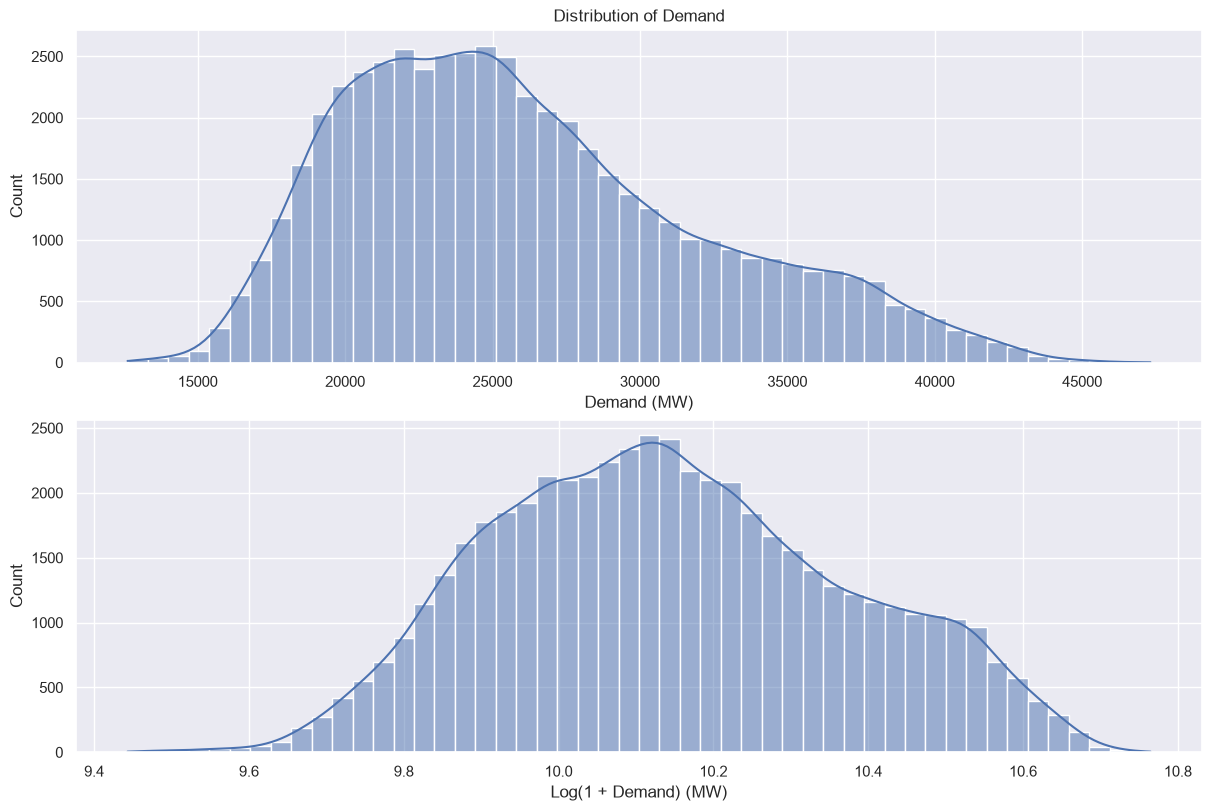

In [5]:
demand["log_demand"] = np.log1p(demand["true_demand_mw"])

fig, axes = plt.subplots(2, 1, figsize = (12, 8), constrained_layout = True)

sns.histplot(
    data = demand,
    x = "true_demand_mw",
    bins = 50,
    kde = True,
    ax = axes[0]
)

axes[0].set_title("Distribution of Demand")
axes[0].set_xlabel("Demand (MW)")

sns.histplot(
    data = demand,
    x = "log_demand",
    bins = 50,
    kde = True,
    ax = axes[1]
)

axes[1].set_xlabel("Log(1 + Demand) (MW)")

plt.show()

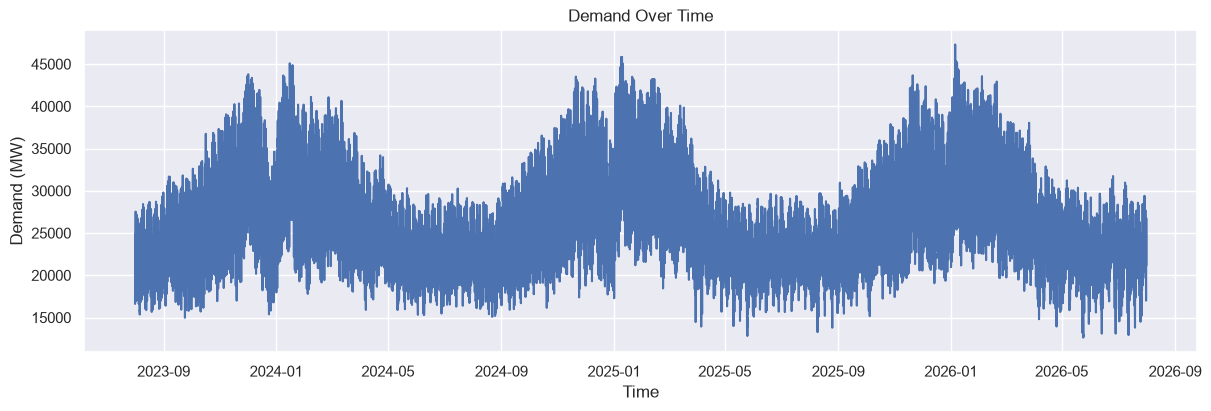

In [6]:
plt.figure(figsize = (12, 4), constrained_layout = True)

sns.lineplot(
    data = demand,
    x = "start_time",
    y = "true_demand_mw"
)

plt.title("Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")

plt.show()

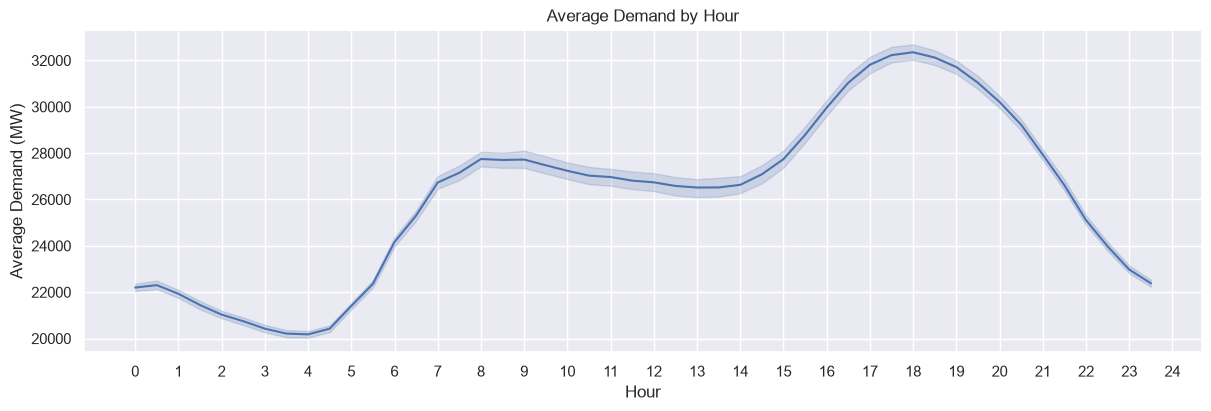

In [7]:
demand["hour"] = demand["start_time"].dt.hour
demand["minute"] = demand["start_time"].dt.minute
demand["time_of_day"] = demand["hour"] + demand["minute"] / 60

plt.figure(figsize = (12, 4), constrained_layout = True)

sns.lineplot(
    data = demand,
    x = "time_of_day",
    y = "true_demand_mw",
    estimator = "mean"
)

plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(0, 25, 1))

plt.show()

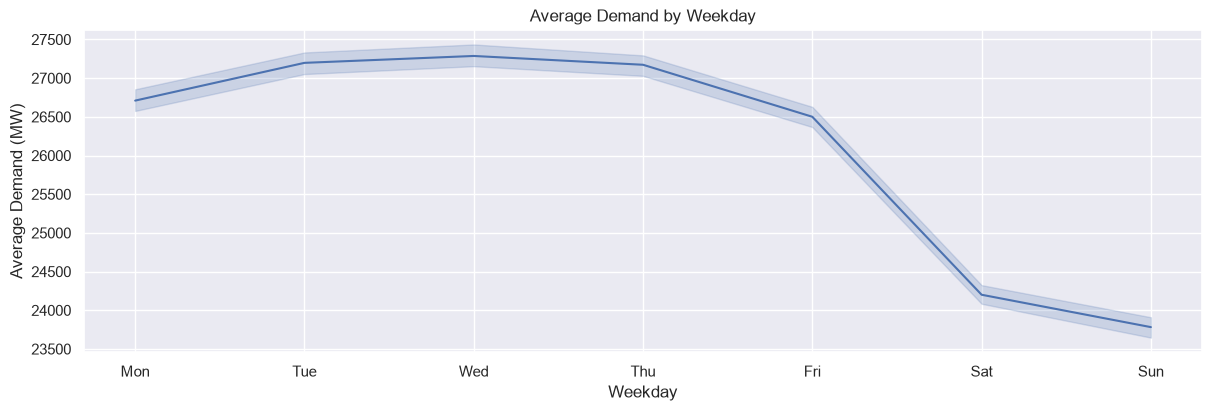

In [8]:
demand["day_of_week"] = demand["start_time"].dt.dayofweek

days_of_week = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize = (12, 4), constrained_layout = True)

sns.lineplot(
    data = demand,
    x = "day_of_week",
    y = "true_demand_mw",
    estimator = "mean"
)

plt.title("Average Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(7), days_of_week)

plt.show()

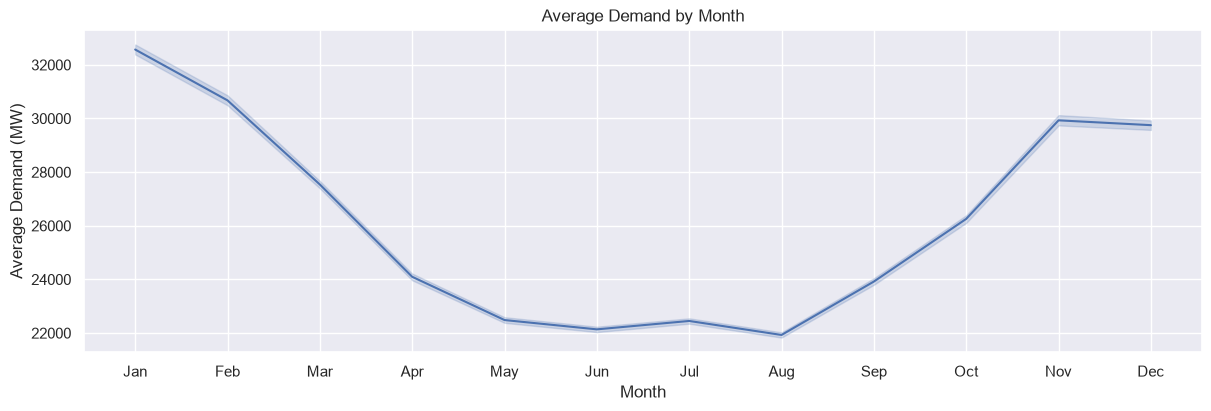

In [9]:
demand["month"] = demand["start_time"].dt.month

months_of_year = ["Jan", "Feb", "Mar", "Apr", "May", "Jun","Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize = (12, 4), constrained_layout = True)

sns.lineplot(
    data = demand,
    x = "month",
    y = "true_demand_mw",
    estimator = "mean"
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(1, 13), months_of_year)

plt.show()

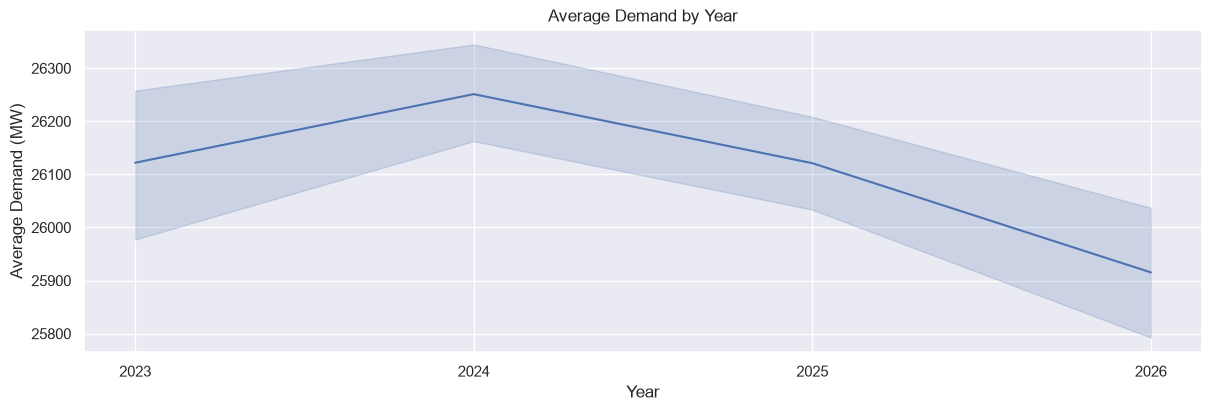

In [10]:
demand["year"] = demand["start_time"].dt.year

yearly_analysis = demand.groupby("year")["true_demand_mw"].mean()

plt.figure(figsize = (12, 4), constrained_layout = True)

sns.lineplot(
    data = demand,
    x = "year",
    y = "true_demand_mw",
    estimator = "mean"
)

plt.title("Average Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Demand (MW)")
plt.xticks(yearly_analysis.index)

plt.show()

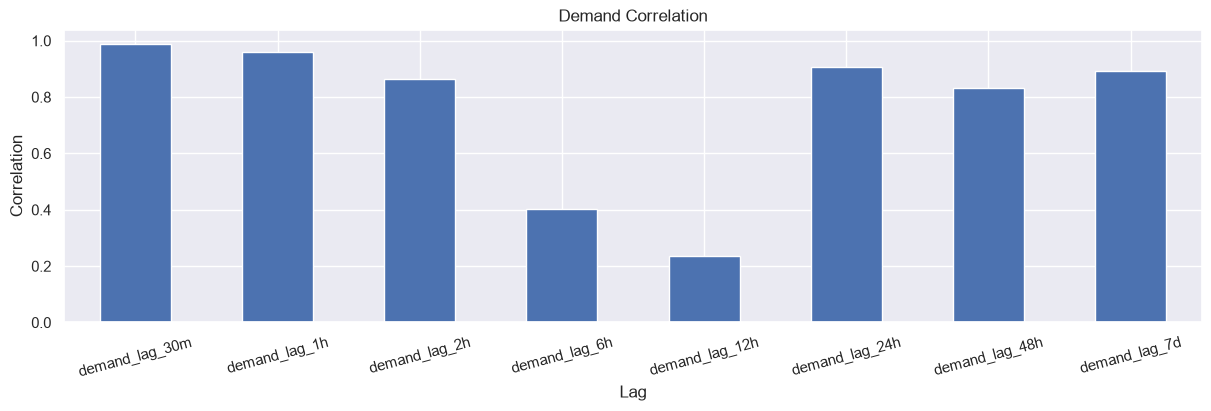

In [11]:
lag_periods = {
    "30m": 1,
    "1h": 2,
    "2h": 4,
    "6h": 12,
    "12h": 24,
    "24h": 48,
    "48h": 96,
    "7d": 336
}

for name, periods in lag_periods.items():
    demand[f"demand_lag_{name}"] = demand["true_demand_mw"].shift(periods)

correlations = {}
for name in lag_periods:
    key = f"demand_lag_{name}"
    correlations[key] = demand["true_demand_mw"].corr(demand[key])

plt.figure(figsize = (12, 4), constrained_layout = True)

pd.Series(correlations).plot(
    kind = "bar"
)

plt.title("Demand Correlation")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.xticks(rotation = 15)

plt.show()

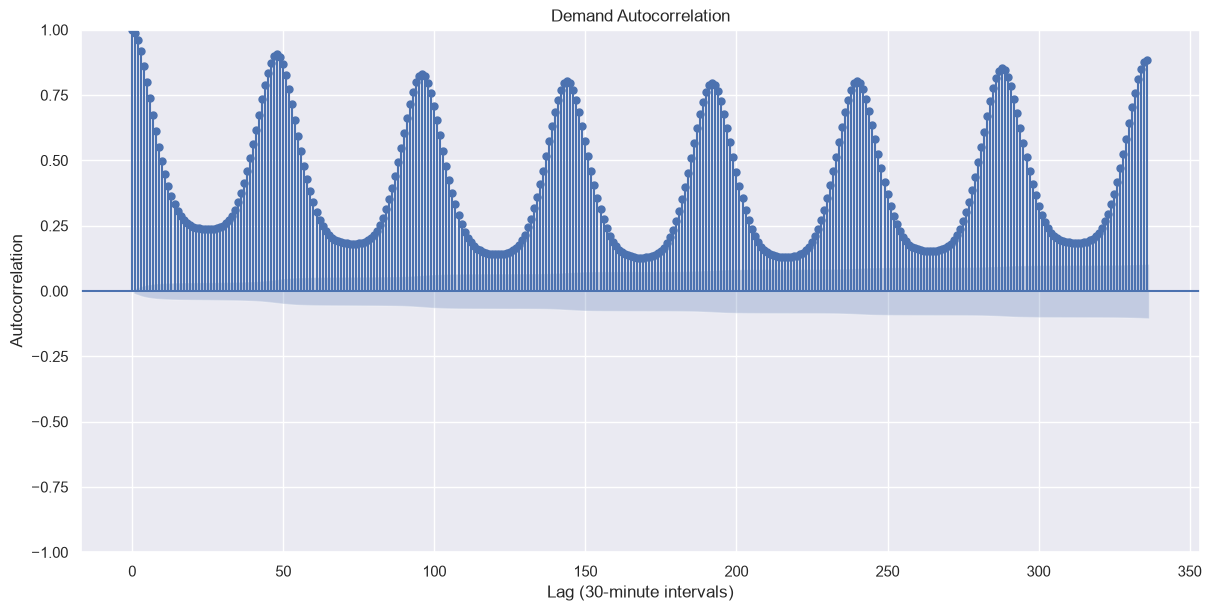

In [12]:
fig, ax = plt.subplots(figsize = (12, 6), constrained_layout = True)

plot_acf(
    demand["true_demand_mw"],
    lags = 336,
    ax = ax
)

plt.title("Demand Autocorrelation")
plt.xlabel("Lag (30-minute intervals)")
plt.ylabel("Autocorrelation")

plt.show()